In [1]:
!pip uninstall -y torch torchvision torchaudio
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118

Found existing installation: torch 2.10.0+cu128
Uninstalling torch-2.10.0+cu128:
  Successfully uninstalled torch-2.10.0+cu128
Found existing installation: torchvision 0.25.0+cu128
Uninstalling torchvision-0.25.0+cu128:
  Successfully uninstalled torchvision-0.25.0+cu128
Found existing installation: torchaudio 2.10.0+cu128
Uninstalling torchaudio-2.10.0+cu128:
  Successfully uninstalled torchaudio-2.10.0+cu128
Looking in indexes: https://download.pytorch.org/whl/cu118
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.2/23.2 MB 86.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 875.6/875.6 kB 52.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.1/13.1 MB 114.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 663.9/663.9 MB 2.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 417.9/417.9 MB 3.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 168.4/168.4 MB 8.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/mnassrib/jena-climate/jena_climate_2009_2016.csv


# Data Preprocessing:

In [3]:
df=pd.read_csv("/kaggle/input/datasets/mnassrib/jena-climate/jena_climate_2009_2016.csv")
df.head()

,Date Time,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
0,01.01.2009 00:10:00,996.52,-8.02,265.40,-8.90,93.3,3.33,3.11,0.22,1.94,3.12,1307.75,1.03,1.75,152.3
1,01.01.2009 00:20:00,996.57,-8.41,265.01,-9.28,93.4,3.23,3.02,0.21,1.89,3.03,1309.80,0.72,1.50,136.1
2,01.01.2009 00:30:00,996.53,-8.51,264.91,-9.31,93.9,3.21,3.01,0.20,1.88,3.02,1310.24,0.19,0.63,171.6
3,01.01.2009 00:40:00,996.51,-8.31,265.12,-9.07,94.2,3.26,3.07,0.19,1.92,3.08,1309.19,0.34,0.50,198.0
4,01.01.2009 00:50:00,996.51,-8.27,265.15,-9.04,94.1,3.27,3.08,0.19,1.92,3.09,1309.00,0.32,0.63,214.3


In [4]:
numeric_cols = df.select_dtypes(include='number').columns
df[numeric_cols] = df[numeric_cols].clip(lower=0)
df

,Date Time,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
0,01.01.2009 00:10:00,996.52,0.0,265.40,0.0,93.30,3.33,3.11,0.22,1.94,3.12,1307.75,1.03,1.75,152.3
1,01.01.2009 00:20:00,996.57,0.0,265.01,0.0,93.40,3.23,3.02,0.21,1.89,3.03,1309.80,0.72,1.50,136.1
2,01.01.2009 00:30:00,996.53,0.0,264.91,0.0,93.90,3.21,3.01,0.20,1.88,3.02,1310.24,0.19,0.63,171.6
3,01.01.2009 00:40:00,996.51,0.0,265.12,0.0,94.20,3.26,3.07,0.19,1.92,3.08,1309.19,0.34,0.50,198.0
4,01.01.2009 00:50:00,996.51,0.0,265.15,0.0,94.10,3.27,3.08,0.19,1.92,3.09,1309.00,0.32,0.63,214.3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
420546,31.12.2016 23:20:00,1000.07,0.0,269.10,0.0,73.10,4.52,3.30,1.22,2.06,3.30,1292.98,0.67,1.52,240.0
420547,31.12.2016 23:30:00,999.93,0.0,269.81,0.0,69.71,4.77,3.32,1.44,2.07,3.32,1289.44,1.14,1.92,234.3
420548,31.12.2016 23:40:00,999.82,0.0,270.01,0.0,67.91,4.84,3.28,1.55,2.05,3.28,1288.39,1.08,2.00,215.2
420549,31.12.2016 23:50:00,999.81,0.0,268.94,0.0,71.80,4.46,3.20,1.26,1.99,3.20,1293.56,1.49,2.16,225.8


we know that wind direction is also important along with speed. so, we'll change the wv, max wv and deg columns into the x and y components of the wind(so that model doesn't differentiate b/w 10deg and 350deg.)

In [5]:
wv = df.pop('wv (m/s)')
max_wv = df.pop('max. wv (m/s)')
wd_rad = df.pop('wd (deg)') * np.pi / 180
df['Wx'] = wv * np.cos(wd_rad)
df['Wy'] = wv * np.sin(wd_rad)
df['max Wx'] = max_wv * np.cos(wd_rad)
df['max Wy'] = max_wv * np.sin(wd_rad)
df

,Date Time,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),Wx,Wy,max Wx,max Wy
0,01.01.2009 00:10:00,996.52,0.0,265.40,0.0,93.30,3.33,3.11,0.22,1.94,3.12,1307.75,-0.911955,0.478787,-1.549439,0.813474
1,01.01.2009 00:20:00,996.57,0.0,265.01,0.0,93.40,3.23,3.02,0.21,1.89,3.03,1309.80,-0.518797,0.499249,-1.080827,1.040103
2,01.01.2009 00:30:00,996.53,0.0,264.91,0.0,93.90,3.21,3.01,0.20,1.88,3.02,1310.24,-0.187962,0.027756,-0.623242,0.092032
3,01.01.2009 00:40:00,996.51,0.0,265.12,0.0,94.20,3.26,3.07,0.19,1.92,3.08,1309.19,-0.323359,-0.105066,-0.475528,-0.154508
4,01.01.2009 00:50:00,996.51,0.0,265.15,0.0,94.10,3.27,3.08,0.19,1.92,3.09,1309.00,-0.264351,-0.180328,-0.520442,-0.355021
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
420546,31.12.2016 23:20:00,1000.07,0.0,269.10,0.0,73.10,4.52,3.30,1.22,2.06,3.30,1292.98,-0.335000,-0.580237,-0.760000,-1.316359
420547,31.12.2016 23:30:00,999.93,0.0,269.81,0.0,69.71,4.77,3.32,1.44,2.07,3.32,1289.44,-0.665237,-0.925775,-1.120399,-1.559200
420548,31.12.2016 23:40:00,999.82,0.0,270.01,0.0,67.91,4.84,3.28,1.55,2.05,3.28,1288.39,-0.882516,-0.622547,-1.634290,-1.152865
420549,31.12.2016 23:50:00,999.81,0.0,268.94,0.0,71.80,4.46,3.20,1.26,1.99,3.20,1293.56,-1.038776,-1.068197,-1.505877,-1.548527


we'll also have to do smthn with the time col. 0 hours and 23 hours are far apart numerically, but actually very close. I searched for a method and found that it can be encoded as sine and cos waves, to mimic the periodicity.

In [6]:
df['Date Time'] = pd.to_datetime(df['Date Time'], format='%d.%m.%Y %H:%M:%S')
timestamp_s = df['Date Time'].map(pd.Timestamp.timestamp)

day = 24 * 60 * 60
year = 365.2425 * day

df['Day sin']  = np.sin(timestamp_s * (2 * np.pi / day))
df['Day cos']  = np.cos(timestamp_s * (2 * np.pi / day))
df['Year sin'] = np.sin(timestamp_s * (2 * np.pi / year))
df['Year cos'] = np.cos(timestamp_s * (2 * np.pi / year))

df = df.set_index('Date Time')

# Building the model


First, we'll define the train/test split. we will not randomise the data as that would also mess up with the time. so, first 70% will be train data and rem 30 will be test and validation.

In [7]:
n = len(df)
train_df = df.iloc[: int(n * 0.7)]
val_df   = df.iloc[int(n * 0.7): int(n * 0.9)]
test_df  = df.iloc[int(n * 0.9):]

now we'll normalise(z-norm) our data bcz of very different numerical values

In [8]:
mean = train_df.mean()
std = train_df.std()

train_norm = (train_df - mean) / std
val_norm   = (val_df - mean) / std
test_norm  = (test_df - mean) / std

we'll make the slide windows for the 72 hour data predicting the next 12 hours. the data is of every 10 minutes, so 72 hour gets 432 inputs and 12 hour gives 72 outputs. we'll start with a slider of 432+72=504 rows of data. then slide one step at a time. this will generate training examples for our model.

In [9]:
import torch
from torch.utils.data import Dataset, DataLoader

INPUT_WIDTH = 432   # 72 hours * 6 steps/hour
OUT_STEPS   = 72    # 12 hours * 6 steps/hour
TARGET_COL  = 'T (degC)'
#we'll have to convert the dataframe to numpy array bcuz it is faster and we need that on these thousands of training sets
class WeatherDataset(Dataset):
    def __init__(self, df, input_width=INPUT_WIDTH, out_steps=OUT_STEPS, target_col=TARGET_COL):
        self.input_width = input_width
        self.out_steps = out_steps
        self.features = df.values.astype('float32')
        self.target_idx = df.columns.get_loc(target_col)
        self.total_window = input_width + out_steps

    def __len__(self):
        return len(self.features) - self.total_window + 1#this is to limit find number of valid window positions
#the below code is to separate the first 432 rows as input and the next 72 rows as target variable. also, we'll convert this data to tensor, to work with it.
    def __getitem__(self, idx):
        window = self.features[idx : idx + self.total_window]
        x = window[:self.input_width]
        y = window[self.input_width:, self.target_idx]
        return torch.from_numpy(x), torch.from_numpy(y)

BATCH_SIZE = 64
train_loader = DataLoader(WeatherDataset(train_norm), batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(WeatherDataset(val_norm),   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(WeatherDataset(test_norm),  batch_size=BATCH_SIZE, shuffle=False)

first we declared the shape of one linear layer sized to output all 4 gates at once (no data flows yet). Then in forward, we combined x and h_prev, ran that through the layer in a single matmul, and split the result into 4 equal chunks which line up with i, f, g, o purely because of the fixed order we wrote them in. then we defined our 3 gates based on the activations they use. g is the candidate cell state, uses tanh to output from -1 to 1 and has some context relevant to our input. then we made long and short term memory using their formula.

In [10]:
import torch.nn as nn

class cell(nn.Module):
    def __init__(self, input_size, hidden_size): 
        super().__init__()
        self.hidden_size = hidden_size
        self.gates = nn.Linear(input_size + hidden_size, 4 * hidden_size)
#this takes input size as current+hidden and gives an output of 4*hidden size. this will help us run all 4 separate gates in one layer.
    def forward(self, x, h_prev, c_prev):
        combined = torch.cat([x, h_prev], dim=1) #returns combined shape of current input and prev hidden state
        i, f, g, o = self.gates(combined).chunk(4, dim=1)
#the chunking will happen in the determined order of all 4 gate states
        i = torch.sigmoid(i)   # input gate
        f = torch.sigmoid(f)   # forget gate
        g = torch.tanh(g)      # candidate cell state values
        o = torch.sigmoid(o)   # output gate

        c_next = f * c_prev + i * g
        h_next = o * torch.tanh(c_next)
        return h_next, c_next

Both new values get returned to the loop that's driving the cell across all 432 timesteps. before that loop even starts, h and c are manually created as zeros, since t=0 has no real predecessor. at every timestep, the current h_prev and c_prev go in, a new h and c come out, the new h gets permanently saved into the output sequence and both the new h and c get carried forward as next timestep's "previous" values. except c is never saved anywhere else, it only ever survives by being passed along, one step at a time, until the loop ends.

In [11]:
class layer(nn.Module):
    def __init__(self, input_size, hidden_size):
        super().__init__()
        self.cell = cell(input_size, hidden_size)
        self.hidden_size = hidden_size
#we'll input x and initiate h and c as 0, at 0 timestamp
    def forward(self, x):
        batch_size, seq_len, _ = x.shape
        h = torch.zeros(batch_size, self.hidden_size, device=x.device)
        c = torch.zeros(batch_size, self.hidden_size, device=x.device)

        outputs = []
        for t in range(seq_len):
            h, c = self.cell(x[:, t, :], h, c)
            outputs.append(h.unsqueeze(1))#unsqueeze reshapes our matrix

        return torch.cat(outputs, dim=1), (h, c)


now, we'll pass this output[] array of all our hidden states into the 2nd layer. this is exactly the same lstm structure, just a different instance. the input for each timestep in layer 2 is the hidden state of the layer 1(t=500 is h500 for eg). each time step gets 64 hidden state values to ultimately output 64 vectors. this is converted to 72 temperature values which is our target value.

In [12]:
class stacking(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers):
        super().__init__()
        self.layers = nn.ModuleList([
            layer(input_size if i == 0 else hidden_size, hidden_size)
            for i in range(num_layers)
        ])

    def forward(self, x):
        for layer in self.layers:
            x, (h, c) = layer(x)
        return x, (h, c)

class weatherpred(nn.Module):
    def __init__(self, n_features, hidden_size=64, num_layers=2, out_steps=OUT_STEPS):
        super().__init__()
        self.lstm = stacking(n_features, hidden_size, num_layers)
        self.head = nn.Linear(hidden_size, out_steps)

    def forward(self, x):
        _, (h_last, _) = self.lstm(x)
        return self.head(h_last)
        

In [13]:
!nvidia-smi

Tue Jun 23 17:55:41 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.159.04             Driver Version: 580.159.04     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla P100-PCIE-16GB           Off |   00000000:00:04.0 Off |                    0 |
| N/A   36C    P0             26W /  250W |       0MiB /  16384MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

# Training

In [14]:
#training this model
import torch.optim as optim

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
n_features = train_norm.shape[1]
model = weatherpred(n_features=n_features, hidden_size=64, num_layers=2).to(device)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    total_loss = 0.0
    with torch.set_grad_enabled(train):
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            preds = model(x)
            loss = criterion(preds, y)
            if train:
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
            total_loss += loss.item() * x.size(0)
    return total_loss / len(loader.dataset)

EPOCHS = 15
for epoch in range(EPOCHS):
    train_loss = run_epoch(train_loader, train=True)
    val_loss = run_epoch(val_loader, train=False)
    print(f"Epoch {epoch+1}/{EPOCHS} - train_loss: {train_loss:.4f} - val_loss: {val_loss:.4f}")


Epoch 1/15 - train_loss: 0.0553 - val_loss: 0.0536
Epoch 2/15 - train_loss: 0.0367 - val_loss: 0.0610
Epoch 3/15 - train_loss: 0.0304 - val_loss: 0.0627
Epoch 4/15 - train_loss: 0.0250 - val_loss: 0.0635
Epoch 5/15 - train_loss: 0.0193 - val_loss: 0.0718
Epoch 6/15 - train_loss: 0.0151 - val_loss: 0.0776
Epoch 7/15 - train_loss: 0.0128 - val_loss: 0.0798
Epoch 8/15 - train_loss: 0.0107 - val_loss: 0.0803
Epoch 9/15 - train_loss: 0.0097 - val_loss: 0.0807
Epoch 10/15 - train_loss: 0.0085 - val_loss: 0.0773
Epoch 11/15 - train_loss: 0.0085 - val_loss: 0.0799
Epoch 12/15 - train_loss: 0.0072 - val_loss: 0.0822
Epoch 13/15 - train_loss: 0.0068 - val_loss: 0.0837
Epoch 14/15 - train_loss: 0.0067 - val_loss: 0.0812
Epoch 15/15 - train_loss: 0.0061 - val_loss: 0.0814


In [15]:
torch.save(model.state_dict(), '/kaggle/working/weather_forecaster.pth')
print("Model saved.")

Model saved.


In [16]:
target_mean = mean[TARGET_COL]
target_std = std[TARGET_COL]

def denormalize(values):
    return values * target_std + target_mean

# Evaluation

In [17]:
model.eval()
all_preds, all_targets = [], []

with torch.no_grad():
    for x, y in test_loader:
        x, y = x.to(device), y.to(device)
        preds = model(x)
        all_preds.append(preds.cpu())
        all_targets.append(y.cpu())

all_preds = torch.cat(all_preds, dim=0)      # (n_samples, 72)
all_targets = torch.cat(all_targets, dim=0)  # (n_samples, 72)

In [18]:
preds_real = denormalize(all_preds)
targets_real = denormalize(all_targets)

mae = (preds_real - targets_real).abs().mean().item()
rmse = torch.sqrt(((preds_real - targets_real) ** 2).mean()).item()

print(f"Test MAE: {mae:.3f} °C")
print(f"Test RMSE: {rmse:.3f} °C")

Test MAE: 1.602 °C
Test RMSE: 2.192 °C


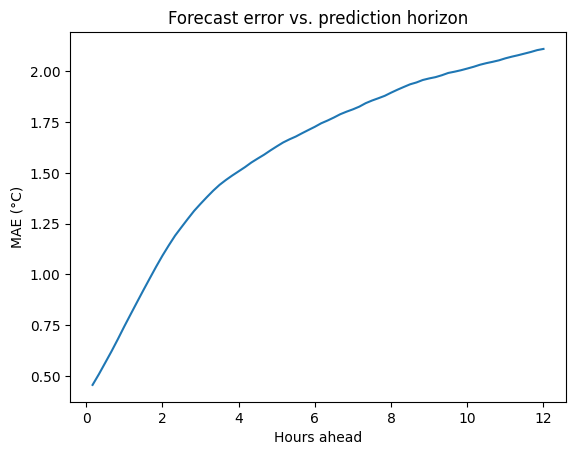

In [19]:
import matplotlib.pyplot as plt

per_step_mae = (preds_real - targets_real).abs().mean(dim=0)  # (72,)
hours = torch.arange(1, OUT_STEPS + 1) / 6  # 10-min steps → hours

plt.plot(hours, per_step_mae.numpy())
plt.xlabel('Hours ahead')
plt.ylabel('MAE (°C)')
plt.title('Forecast error vs. prediction horizon')
plt.show()

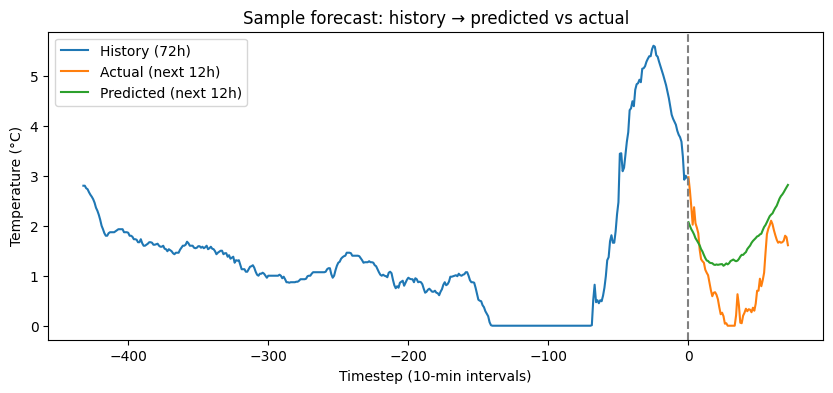

In [20]:
sample_idx = 0
x_sample, y_sample = test_loader.dataset[sample_idx]
x_sample_batched = x_sample.unsqueeze(0).to(device)

with torch.no_grad():
    pred_sample = model(x_sample_batched).cpu().squeeze(0)

target_col_idx = train_norm.columns.get_loc(TARGET_COL)
history_real = denormalize(x_sample[:, target_col_idx])
true_future_real = denormalize(y_sample)
pred_future_real = denormalize(pred_sample)

plt.figure(figsize=(10, 4))
plt.plot(range(-INPUT_WIDTH, 0), history_real, label='History (72h)')
plt.plot(range(0, OUT_STEPS), true_future_real, label='Actual (next 12h)')
plt.plot(range(0, OUT_STEPS), pred_future_real, label='Predicted (next 12h)')
plt.axvline(0, color='gray', linestyle='--')
plt.legend()
plt.xlabel('Timestep (10-min intervals)')
plt.ylabel('Temperature (°C)')
plt.title('Sample forecast: history → predicted vs actual')
plt.show()